In [1]:
import yaml
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
plt.rcParams['svg.fonttype'] = 'none'

In [2]:
# Get gene trait associations
!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet -o /home/dnanexus/data_dir/
# !dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/loftee_mac20_associations_bh_corrected.parquet -o /home/dnanexus/data_dir/

!dx download project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/REGENIE_results/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet -o /home/dnanexus/data_dir/

gene_trait_df = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet')
    .filter(pl.col('pval_fdr')<=0.05)
    .select(['region', 'phenotype', 'pval_fdr'])
)

loftee_corrs = (
    pl.read_parquet('/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_correlations.parquet')
    .with_columns(
        loftee_corr = pl.col('correlation'),
        loftee_corr_abs = pl.col('correlation').abs(),
        loftee_corr_dir = pl.col('correlation')/pl.col('correlation').abs(),
    )
    .select(['region', 'phenotype', 'loftee_corr', 'loftee_corr_abs', 'loftee_corr_dir']) 
)

gene_trait_df = (
    gene_trait_df
    .filter(
        pl.col('region') == 'ENSG00000130164',
        pl.col('phenotype') == 'ldl_direct_int'
    )
)

gene_trait_df = (
    gene_trait_df
    .join(loftee_corrs, on=['region', 'phenotype'], how='inner')
    .drop_nans()
    .sort('loftee_corr_abs', descending=True)
    .unique(subset=["region"], keep="first", maintain_order=True)
)

gene_trait_df

Error: path
"/home/dnanexus/data_dir/regenie_127phenotypes_lofteeHC_mac20_EUR.parquet"
already exists but -f/--overwrite was not set
Error: path "/home/dnanexus/data_dir/regenie_127phenotypes_mac20_lofteeHC_EUR_
correlations.parquet" already exists but -f/--overwrite was not set


region,phenotype,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir
str,str,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""",3.0392e-14,0.104534,0.104534,1.0


In [3]:
# Configuration and paths
mac = 20
pheno_list_type = None

# Initial the exp assay path variable
exp_anno_local = None

# Load phenotype configuration
pheno_config_path = "/home/dnanexus/ukbgym/phenotype_config.yaml"
with open(pheno_config_path) as f:
    pheno_config = yaml.safe_load(f)

if pheno_list_type is not None:
    pheno_list = pheno_config[pheno_list_type]

eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'

# Load annotation configuration
config_path = "/home/dnanexus/ukbgym/config_expAssays.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records).with_columns(
    pl.col("annotation_dir").cast(pl.Int8)
)

all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()

anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i8
"""exp_assays""","""scaled_fitness""","""#6A1B9A""","""aPCA fitness""",1
"""exp_assays""","""LDL_uptake_functional""","""#6A1B9A""","""LDL uptake functional""",-1
"""exp_assays""","""LDLR_cell_surface_abundance""","""#AB47BC""","""LDLR cell surface abundance""",-1
"""missense""","""am_pathogenicity""","""#feb72d""","""AlphaMissense""",1
"""missense""","""score_pai3d""","""#feb72d""","""PrimateAI-3D""",1
…,…,…,…,…
"""protein_domains""","""low_complexity_domain""","""#FF9933""","""Low Complexity Domain""",1
"""loftee_protein_domains""","""loftee_disorder""","""#E31A1C""","""Disordered Domain""",1
"""loftee_protein_domains""","""loftee_lip""","""#1E90FF""","""Linear Interacting Peptides""",1


In [4]:
exp_anno_path = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/experimental_assays"

# exp_anno_filename = "aPCA_Beltran_Nature_2025.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_Marsh_VEP.parquet"
# exp_assay_score_columns = ['scaled_fitness']

# exp_anno_filename = "DMS_ProteinGym_substitutions.parquet"

exp_anno_filename = "LDLR_Roth_Science_2025.parquet"
exp_assay_type_column = 'assay'
exp_assay_score_column = 'score'

LOCAL_EXP_DIR = "/home/dnanexus/data_dir/experimental_assays"
!mkdir -p {LOCAL_EXP_DIR}
!dx download {exp_anno_path}/{exp_anno_filename} -o {LOCAL_EXP_DIR}

exp_anno_local = f'{LOCAL_EXP_DIR}/{exp_anno_filename}'

id_cols = ['ref_aa', 'aa_position', 'alt_aa', 'region']
exp_anno_df = (
    pl.read_parquet(exp_anno_local)
    .filter(pl.col('region').is_in(gene_trait_df['region'].unique()))
    .drop_nulls(subset=id_cols)
    # .select(id_cols + exp_assay_type_columns + exp_assay_score_columns)
    .pivot(
        index=id_cols,
        on=exp_assay_type_column,
        values=exp_assay_score_column
    )
)

exp_assay_columns = list(set(exp_anno_df.columns) - set(id_cols))

exp_assay_columns = ['LDL_uptake_functional', 'LDLR_cell_surface_abundance']
exp_anno_df = exp_anno_df.select(id_cols + exp_assay_columns)

exp_anno_df

Error: path
"/home/dnanexus/data_dir/experimental_assays/LDLR_Roth_Science_2025.parquet"
already exists but -f/--overwrite was not set


/tmp/ipykernel_478946/2925430958.py:24: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


ref_aa,aa_position,alt_aa,region,LDL_uptake_functional,LDLR_cell_surface_abundance
str,i64,str,str,f64,f64
"""G""",2,"""L""","""ENSG00000130164""",-0.042187,0.90099
"""G""",2,"""W""","""ENSG00000130164""",0.985631,1.012781
"""G""",2,"""A""","""ENSG00000130164""",0.964176,1.021534
"""G""",2,"""Y""","""ENSG00000130164""",-0.026747,1.062286
"""G""",2,"""M""","""ENSG00000130164""",1.012579,1.130779
…,…,…,…,…,…
"""G""",343,"""Q""","""ENSG00000130164""",null,null
"""A""",348,"""W""","""ENSG00000130164""",null,null
"""A""",348,"""Y""","""ENSG00000130164""",null,null


In [5]:
RAP_ANNO_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/wgs/qced_maf1e-3_loftee_olink_genes/qced_maf1e-3_loftee_olink_genes_EURunrelated"
LOCAL_ANNO_DIR = "/home/dnanexus/data_dir"

# ANNO_FILE = "annotations_fillna_ukbgym.parquet"
ANNO_FILE = "annotations_fillna_ukbgym_with_mane.parquet"

!dx download {RAP_ANNO_DIR}/{ANNO_FILE} -o {LOCAL_ANNO_DIR}/{ANNO_FILE}
anno = pl.scan_parquet(f"{LOCAL_ANNO_DIR}/{ANNO_FILE}")

# Join new annotation if specified above
if exp_anno_local is not None:
    anno = (
        anno
        .filter(
            pl.col('amino_acids').is_not_null(),
            pl.col('amino_acids').str.contains("/"),
            ~pl.col('protein_position').str.contains("-")
        )
        .with_columns(
            pl.col("amino_acids").str.split("/").list.get(0).alias("ref_aa"),
            pl.col("amino_acids").str.split("/").list.get(1).alias("alt_aa"),
            pl.col("protein_position").str.split("/").list.get(0).cast(pl.Int64).alias("aa_position")
        )

        .join(
            exp_anno_df.lazy(),
            on=['ref_aa', 'aa_position', 'alt_aa', 'region'],
            how='left'
        )

        # Restrict to variants with experimental assay data
        .drop_nulls(exp_assay_columns)
    )


anno = (
    anno
    .filter(
        # Filter to gene regions of interest
        (pl.col('region').is_in(gene_trait_df['region'].unique())),
        
        # Choose VEP consequence
        # (pl.col('consequence_missense_variant') == True),
        # (pl.col('consequence_synonymous_variant') == True),

        # Filter for missense variants that we can merge with exp assay data
        # (pl.col('amino_acids').is_not_null()) & (pl.col('amino_acids').str.contains("/")) & (~pl.col('protein_position').str.contains("-")),

        # Choose CDS
        # (pl.col('vep_cds_relaxed')==True),

        # Choose non CDS only
        # ((pl.col('vep_cds_relaxed')==False) & (pl.col('mane_cds')==False) & (pl.col('non_mane_cds')==False)),
        
        # Choose MobiDB region
        # (pl.col('mobi_lip_full') == True),
        # (pl.col('mobi_disorder_full') == True),

        # Choose Gene Body
        # ((pl.col('consequence_upstream_gene_variant') == False) & (pl.col('consequence_downstream_gene_variant') == False)),

        # Only SNPs
        (pl.col('ref').str.len_chars()==1) & (pl.col('alt').str.len_chars()==1)
    )
    
)



selected_categories = ['missense', 'genetic_diversity', 'conservation'] # missense
# selected_categories = ['protein_domains'] # protein domains
# selected_categories = ['loftee_protein_domains'] # protein domains
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # splicing
# selected_categories = ['splicing', 'genetic_diversity', 'conservation'] # synonymous
# selected_categories = ['plof', 'missense', 'genetic_diversity', 'conservation', 'splicing', 'regulatory_nondir'] # CDS

selected_annos = anno_config_df.filter(
    pl.col('category').is_in(selected_categories)
)['annotation'].to_list()

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

selected_annos = list(set(selected_annos).intersection(set(existing_annos))) + exp_assay_columns
fillna_cols = [c+'_is_na' for c in selected_annos]

anno = (
    anno
    .select(
        set(['id', 'region']).union(set(selected_annos))
    )
    .collect(engine='streaming')
    # .drop_nulls()
)

anno

Error: path
"/home/dnanexus/data_dir/annotations_fillna_ukbgym_with_mane.parquet" already
exists but -f/--overwrite was not set


/tmp/ipykernel_478946/3556430426.py:81: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.
/tmp/ipykernel_478946/3556430426.py:91: DeprecationWarning: `is_in` with a collection of the same datatype is ambiguous and deprecated.
Please use `implode` to return to previous behavior.

See https://github.com/pola-rs/polars/issues/22149 for more information.


gpn_score,cadd_raw,esmscoremissense,score_pai3d,LDLR_cell_surface_abundance,region,LDL_uptake_functional,id,am_pathogenicity,verphylop
f32,f32,f32,f32,f64,str,f64,str,f32,f32
-4.83,-0.694953,-7.192,0.481507,1.031644,"""ENSG00000130164""",1.070936,"""chr19:11113342:C:G""",0.159,-3.102
-6.95,4.385301,-8.156,0.580046,-0.129279,"""ENSG00000130164""",0.040287,"""chr19:11113362:C:T""",0.2483,2.454
-7.89,4.350925,-9.778,0.604491,0.696494,"""ENSG00000130164""",1.276075,"""chr19:11113374:A:C""",0.6225,8.581
-7.36,3.3911,-7.135,0.548279,0.997938,"""ENSG00000130164""",1.022527,"""chr19:11113337:C:G""",0.1068,0.65
-7.26,5.934125,-11.319,0.740116,0.121253,"""ENSG00000130164""",1.097567,"""chr19:11113307:C:T""",0.5689,4.45
…,…,…,…,…,…,…,…,…,…
-10.54,4.970818,-11.219,0.961773,0.107663,"""ENSG00000130164""",0.169829,"""chr19:11116147:T:C""",0.964,8.684
-1.86,0.711283,-5.093,0.414374,1.108622,"""ENSG00000130164""",0.963509,"""chr19:11116163:C:G""",0.124,-0.851
-4.8,1.554851,-6.665,0.468412,0.938654,"""ENSG00000130164""",1.022348,"""chr19:11116861:C:A""",0.1149,-0.329


In [6]:
melted_anno = (
    anno.lazy()

    .select(
        set(['id', 'region']).union(set(selected_annos))
    )

    .unpivot(
        index=["id", "region"],
        on=selected_annos,
        variable_name="annotation",
        value_name="annotation_score"
    )
    .with_columns(
        pl.col("annotation_score").cast(pl.Float32),
        pl.col("region").cast(pl.Utf8),
    )
        
    # Keep variants that don't have fillna annotation
    # .join(
    #     anno_fillna_melted,
    #     on=['id', 'region', 'annotation'],
    #     how='semi'
    # )
    
    .collect(engine='streaming')
)

melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11113342:C:G""","""ENSG00000130164""","""gpn_score""",-4.83
"""chr19:11113362:C:T""","""ENSG00000130164""","""gpn_score""",-6.95
"""chr19:11113374:A:C""","""ENSG00000130164""","""gpn_score""",-7.89
"""chr19:11113337:C:G""","""ENSG00000130164""","""gpn_score""",-7.36
"""chr19:11113307:C:T""","""ENSG00000130164""","""gpn_score""",-7.26
…,…,…,…
"""chr19:11116147:T:C""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.107663
"""chr19:11116163:C:G""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",1.108622
"""chr19:11116861:C:A""","""ENSG00000130164""","""LDLR_cell_surface_abundance""",0.938654


In [7]:
RAP_APPV_DIR = "project-Gyp4fvjJg0yFZ374KvP9bGFJ:/processed_data/ukbgym/avg_pheno_per_var"
LOCAL_APPV_DIR = "/home/dnanexus/data_dir"

APPV_FILE = "loftee_mac20_quant_pheno_assocs_EURunrelated_appv_percentiles.parquet"

!dx download {RAP_APPV_DIR}/{APPV_FILE} -o {LOCAL_APPV_DIR}/{APPV_FILE}
appv = pl.scan_parquet(f"{LOCAL_APPV_DIR}/{APPV_FILE}")

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique()).lazy()

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
    .select(
        ['id', 'phenotype', 'mean_pheno_value', 'n_individuals']
    )
)
# unique_phenotypes = appv.select('phenotype').unique().collect(engine='streaming').to_series()

Error: path "/home/dnanexus/data_dir/loftee_mac20_quant_pheno_assocs_EURunrela
ted_appv_percentiles.parquet" already exists but -f/--overwrite was not set


In [8]:
from scipy.stats import spearmanr, norm

n_bootstrap = 1_000
ci_alpha = 0.05
z_crit = norm.ppf(1 - ci_alpha / 2)  # 1.96 for 95% CI

seed = 42

# --- 1. Collect the pre-correlation data ---
region_keys = gene_trait_df.lazy().select(pl.col('region').unique())
anno_ids_lazy = melted_anno.lazy().join(
    region_keys, on='region', how='semi'
).select(pl.col('id').unique())

pre_corr_data = (
    appv
    .join(anno_ids_lazy, on="id", how="semi")
    .join(
        melted_anno.lazy().drop([c for c in melted_anno.columns if 'is_na' in c]),
        on="id", 
        how="inner"
    )
    .join(
        gene_trait_df["region", "phenotype"].lazy(), 
        on=["region", "phenotype"], 
        how="inner"
    )
    .filter(pl.col('annotation') != 'loftee_hc')
    .collect(engine='streaming')
)

# --- 2. Bootstrap Spearman correlation ---
rng = np.random.default_rng(seed)
results = []

for (region, phenotype, annotation), group in pre_corr_data.group_by(['region', 'phenotype', 'annotation']):
    scores = group['annotation_score'].to_numpy().astype(np.float64)
    pheno_vals = group['mean_pheno_value'].to_numpy().astype(np.float64)
    
    # Drop NaN pairs
    mask = ~(np.isnan(scores) | np.isnan(pheno_vals))
    scores, pheno_vals = scores[mask], pheno_vals[mask]
    n = len(scores)
    
    if n < 3 or len(np.unique(scores)) < 2 or len(np.unique(pheno_vals)) < 2:
        continue
    
    # Original correlation
    orig_corr, _ = spearmanr(scores, pheno_vals)
    
    # Bootstrap
    boot_corrs = []
    for _ in range(n_bootstrap):
        idx = rng.integers(0, n, size=n)
        s, p = scores[idx], pheno_vals[idx]
        if len(np.unique(s)) > 1 and len(np.unique(p)) > 1:
            r, _ = spearmanr(s, p)
            boot_corrs.append(r)
        
        else:
            boot_corrs.append(np.nan)
    
    boot_corrs = np.array(boot_corrs)
    mean_boot_corr = np.nanmean(boot_corrs)

    # Bootstrap percentile CI
    # ci_low = np.percentile(boot_corrs, 100 * ci_alpha / 2) if len(boot_corrs) > 10 else np.nan
    # ci_high = np.percentile(boot_corrs, 100 * (1 - ci_alpha / 2)) if len(boot_corrs) > 10 else np.nan
    
    # Gaussian SE-based CI: corr ± z * (std of bootstrap distribution)
    se = np.std(boot_corrs)/np.sqrt(len(boot_corrs)) if len(boot_corrs) > 10 else np.nan
    ci_low = orig_corr - z_crit * se
    ci_high = orig_corr + z_crit * se

    results.append({
        'region': region, 
        'phenotype': phenotype, 
        'annotation': annotation,
        'n_variants': n, 
        'correlation': orig_corr, 
        'mean_correlation': mean_boot_corr,
        'ci_low': ci_low, 
        'ci_high': ci_high,
    })

final_lazy_plan = pl.DataFrame(results)

# --- 3. Join with beta directions and annotation directions ---
correlation_df = (
    final_lazy_plan
    .join(anno_config_df.drop('category').unique(), on='annotation')
    .join(gene_trait_df, on=['region', 'phenotype'])
    .with_columns(
        # corr_beta = pl.col('correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        corr_beta = pl.col('mean_correlation') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_low_beta = pl.col('ci_low') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
        ci_high_beta = pl.col('ci_high') * pl.col('loftee_corr_dir') * pl.col('annotation_dir'),
    )
    # When direction flips the sign, ci_low/ci_high swap — fix ordering
    .with_columns(
        ci_low_beta_final = pl.min_horizontal('ci_low_beta', 'ci_high_beta'),
        ci_high_beta_final = pl.max_horizontal('ci_low_beta', 'ci_high_beta'),
    )
    .drop(['ci_low_beta', 'ci_high_beta'])
    .rename({'ci_low_beta_final': 'ci_low_beta', 'ci_high_beta_final': 'ci_high_beta'})
)

print("Final DataFrame shape:", correlation_df.shape)
correlation_df

Final DataFrame shape: (8, 18)


region,phenotype,annotation,n_variants,correlation,mean_correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta
str,str,str,i64,f64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64
"""ENSG00000130164""","""ldl_direct_int""","""verphylop""",401,0.181003,0.180362,0.178008,0.183998,"""#942c80""","""Vertebrate PhyloP""",1,3.0392e-14,0.104534,0.104534,1.0,0.180362,0.178008,0.183998
"""ENSG00000130164""","""ldl_direct_int""","""cadd_raw""",401,0.290017,0.290621,0.287265,0.292768,"""#1f77b4""","""CADD Raw""",1,3.0392e-14,0.104534,0.104534,1.0,0.290621,0.287265,0.292768
"""ENSG00000130164""","""ldl_direct_int""","""gpn_score""",401,-0.227178,-0.22981,-0.230246,-0.22411,"""#942c80""","""GPN-MSA""",-1,3.0392e-14,0.104534,0.104534,1.0,0.22981,0.22411,0.230246
"""ENSG00000130164""","""ldl_direct_int""","""score_pai3d""",401,0.20017,0.199891,0.19699,0.203349,"""#feb72d""","""PrimateAI-3D""",1,3.0392e-14,0.104534,0.104534,1.0,0.199891,0.19699,0.203349
"""ENSG00000130164""","""ldl_direct_int""","""LDLR_cell_surface_abundance""",401,-0.079823,-0.077929,-0.082893,-0.076754,"""#AB47BC""","""LDLR cell surface abundance""",-1,3.0392e-14,0.104534,0.104534,1.0,0.077929,0.076754,0.082893
"""ENSG00000130164""","""ldl_direct_int""","""LDL_uptake_functional""",401,-0.103766,-0.105532,-0.106904,-0.100628,"""#6A1B9A""","""LDL uptake functional""",-1,3.0392e-14,0.104534,0.104534,1.0,0.105532,0.100628,0.106904
"""ENSG00000130164""","""ldl_direct_int""","""am_pathogenicity""",401,0.212414,0.209331,0.209341,0.215486,"""#feb72d""","""AlphaMissense""",1,3.0392e-14,0.104534,0.104534,1.0,0.209331,0.209341,0.215486
"""ENSG00000130164""","""ldl_direct_int""","""esmscoremissense""",401,-0.196556,-0.194852,-0.199718,-0.193394,"""#feb72d""","""ESM1v""",-1,3.0392e-14,0.104534,0.104534,1.0,0.194852,0.193394,0.199718


In [9]:

consistent_gt = (
    correlation_df
    .drop_nulls().drop_nans()
    .group_by(['region', 'phenotype'])
    .agg(n_annotations = pl.len())
    .filter(pl.col('n_annotations') == correlation_df['annotation'].n_unique())
)

filt_corr_df = correlation_df.filter(pl.col("n_variants") > 20)
filt_corr_df = filt_corr_df.join(consistent_gt, on=['region', 'phenotype'], how='inner')
filt_corr_df

region,phenotype,annotation,n_variants,correlation,mean_correlation,ci_low,ci_high,color,label,annotation_dir,pval_fdr,loftee_corr,loftee_corr_abs,loftee_corr_dir,corr_beta,ci_low_beta,ci_high_beta,n_annotations
str,str,str,i64,f64,f64,f64,f64,str,str,i8,f64,f64,f64,f64,f64,f64,f64,u64
"""ENSG00000130164""","""ldl_direct_int""","""verphylop""",401,0.181003,0.180362,0.178008,0.183998,"""#942c80""","""Vertebrate PhyloP""",1,3.0392e-14,0.104534,0.104534,1.0,0.180362,0.178008,0.183998,8
"""ENSG00000130164""","""ldl_direct_int""","""cadd_raw""",401,0.290017,0.290621,0.287265,0.292768,"""#1f77b4""","""CADD Raw""",1,3.0392e-14,0.104534,0.104534,1.0,0.290621,0.287265,0.292768,8
"""ENSG00000130164""","""ldl_direct_int""","""gpn_score""",401,-0.227178,-0.22981,-0.230246,-0.22411,"""#942c80""","""GPN-MSA""",-1,3.0392e-14,0.104534,0.104534,1.0,0.22981,0.22411,0.230246,8
"""ENSG00000130164""","""ldl_direct_int""","""score_pai3d""",401,0.20017,0.199891,0.19699,0.203349,"""#feb72d""","""PrimateAI-3D""",1,3.0392e-14,0.104534,0.104534,1.0,0.199891,0.19699,0.203349,8
"""ENSG00000130164""","""ldl_direct_int""","""LDLR_cell_surface_abundance""",401,-0.079823,-0.077929,-0.082893,-0.076754,"""#AB47BC""","""LDLR cell surface abundance""",-1,3.0392e-14,0.104534,0.104534,1.0,0.077929,0.076754,0.082893,8
"""ENSG00000130164""","""ldl_direct_int""","""LDL_uptake_functional""",401,-0.103766,-0.105532,-0.106904,-0.100628,"""#6A1B9A""","""LDL uptake functional""",-1,3.0392e-14,0.104534,0.104534,1.0,0.105532,0.100628,0.106904,8
"""ENSG00000130164""","""ldl_direct_int""","""am_pathogenicity""",401,0.212414,0.209331,0.209341,0.215486,"""#feb72d""","""AlphaMissense""",1,3.0392e-14,0.104534,0.104534,1.0,0.209331,0.209341,0.215486,8
"""ENSG00000130164""","""ldl_direct_int""","""esmscoremissense""",401,-0.196556,-0.194852,-0.199718,-0.193394,"""#feb72d""","""ESM1v""",-1,3.0392e-14,0.104534,0.104534,1.0,0.194852,0.193394,0.199718,8


In [10]:
annos_w_inconsistent_assocs = (
    filt_corr_df
    .drop_nulls().drop_nans()
    .select(['region', 'phenotype', 'annotation'])
    .group_by('annotation')
    .agg(n_associations = pl.len())
    .select('n_associations').n_unique()
) - 1

print(f"Annotations with inconsistent associations: {annos_w_inconsistent_assocs}")

# Check if the variant counts are consistent within each (region, phenotype) pair
var_inconsistent = (
    filt_corr_df
    .drop_nans()
    .drop_nulls()
    .group_by(["region", "phenotype"])
    .agg(pl.col("n_variants").n_unique().alias("n_variants_unique"))
    .filter(pl.col("n_variants_unique") > 1)
)
print(f"Inconsistent (region, phenotype) pairs: {var_inconsistent.shape[0]}")

Annotations with inconsistent associations: 0
Inconsistent (region, phenotype) pairs: 0


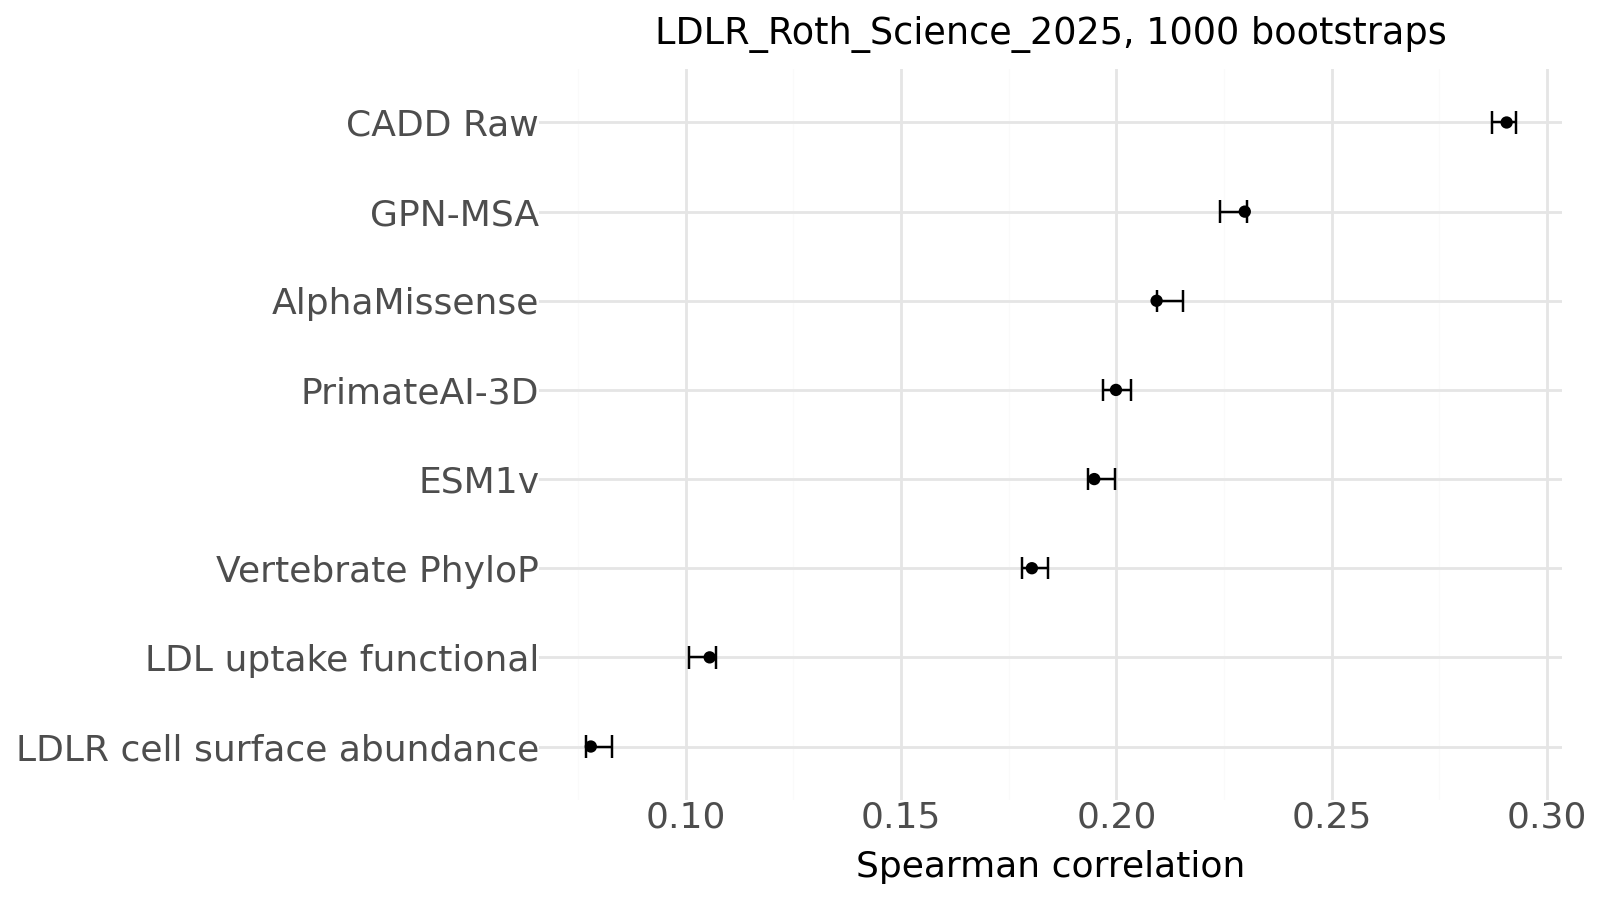

In [11]:
plotting_col = 'corr_beta'
dashed_line_value = 1 if 'rescaled' in plotting_col else 0

# Calculate medians and join back
corr_pl = (
    filt_corr_df
    .drop_nans()
    .with_columns(
        median_corr_beta = pl.col(plotting_col).median().over("annotation")
    )
)

# 2. Determine the categorical order for the labels
ordered_labels = (
    corr_pl
    .sort("median_corr_beta", descending=False)
    .select("label")
    .unique(maintain_order=True)
    .to_series()
)

# 3. Apply the ordering using pl.Enum
corr_pl = corr_pl.with_columns(pl.col("label").cast(pl.Enum(ordered_labels)))

# 4. Create the color dictionary (Polars style)
color_dict = dict(corr_pl.select("annotation", "color").unique().iter_rows())

# Plot
(
    ggplot(corr_pl, aes(x="label", y=plotting_col))
    # + geom_hline(aes(yintercept=dashed_line_value), color='black', linetype='dotted')
    + geom_point(size=1.5)
    + geom_errorbar(aes(ymin="ci_low_beta", ymax="ci_high_beta"), width=0.25)
    + theme_minimal()
    + scale_fill_manual(values=color_dict)
    + labs(
        x="",
        y="Spearman correlation",
        title=f"{exp_anno_filename.replace('.parquet', '')}, {n_bootstrap} bootstraps"
    )
    + coord_flip()
    + theme(
        figure_size=(8, corr_pl['annotation'].n_unique()/2 + 0.5),
        legend_position="none",
        axis_text=element_text(size=13),
        axis_title=element_text(size=13),
        legend_text=element_text(size=13),
        legend_title=element_text(size=13),
        plot_background=element_rect(fill="white", color="white"),
    )
)

In [12]:
import itertools
from scipy.stats import wilcoxon

annotations = filt_corr_df.select(pl.col("annotation")).unique().to_series().to_list()
pairs = list(itertools.combinations(annotations, 2))

results = []
for a, b in pairs:
    # Subset to same gene-trait pairs where both VSMs have values
    df_a = filt_corr_df.filter(pl.col("annotation") == a).select(["region", "phenotype", "corr_beta"])
    df_b = filt_corr_df.filter(pl.col("annotation") == b).select(["region", "phenotype", "corr_beta"])

    merged = df_a.join(df_b, on=["region", "phenotype"], how="inner", suffix="_b")

    if merged.height > 0:
        stat, pval = wilcoxon(merged["corr_beta"].to_numpy(), merged["corr_beta_b"].to_numpy(), alternative="two-sided")
        results.append((a, b, merged.height, stat, pval))

# Make results dataframe
stats_df = pl.DataFrame(
    results,
    schema=["VSM_A", "VSM_B", "N_pairs", "W_stat", "pval_raw"]
)

stats_df.filter(pl.col("pval_raw") < 0.05).sort("pval_raw")
# stats_df.sort("pval_raw")

/tmp/ipykernel_478946/1012804157.py:20: DataOrientationWarning: Row orientation inferred during DataFrame construction. Explicitly specify the orientation by passing `orient="row"` to silence this warning.


VSM_A,VSM_B,N_pairs,W_stat,pval_raw
str,str,i64,f64,f64
